In [106]:
import pandas as pd
import numpy as np

In [ ]:
# Adjust these paths if your CSVs are in a different folder
unit_files = {Impotant things about screens:
-	Admin and lecturer screens are not hidden from users who should not see them. Hiding a navigation item doesn’t prevent the request behind it, so every data query is scoped in the database layer instead.
-	The students are not represented as person or rows, but as an enrolment. This is because different risk status can be marked to the same student in different units under same lecturer.

    "ICT102": "ICT102.csv",
    "ACC100": "ACC100.csv",
    "BUS708": "BUS708.csv",
    "TSL713": "TSL713.csv",
}

# how many assessment slots and whether tut columns exist, per unit
UNIT_SHAPE = {
    "ICT102": {"n_assess": 2, "has_tut": True},
    "ACC100": {"n_assess": 1, "has_tut": True},
    "BUS708": {"n_assess": 2, "has_tut": False},
    "TSL713": {"n_assess": 1, "has_tut": False},
}

ATT_WEEKS = [f"att_w{i}" for i in range(1, 8)]
TUT_WEEKS = [f"tut_w{i}" for i in range(2, 8)]
MAX_ASSESS_SLOTS = 2


In [108]:
frames = []
for unit_code, path in unit_files.items():
    df = pd.read_csv(path)
    df["unit_code"] = unit_code  # not present in raw file - add it back
    shape = UNIT_SHAPE[unit_code]

    # standardize assessments into fixed a1/a2 slots - blank beyond what
    # this unit actually has
    for slot in range(1, MAX_ASSESS_SLOTS + 1):
        score_col, max_col = f"a{slot}_score", f"a{slot}_max"
        if slot > shape["n_assess"]:
            df[score_col] = np.nan
            df[max_col] = np.nan

    # add blank tut columns for units that structurally have none at all
    if not shape["has_tut"]:
        for col in TUT_WEEKS:
            df[col] = np.nan

    frames.append(df)

merged = pd.concat(frames, ignore_index=True)
print(f"Merged dataset: {merged.shape[0]} rows, {merged.shape[1]} columns")
print(merged["unit_code"].value_counts())

Merged dataset: 711 rows, 26 columns
unit_code
ACC100    190
ICT102    186
BUS708    170
TSL713    165
Name: count, dtype: int64


In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------------------------
# Step 2: Encode weekly tutorial values with the locked credit mapping -
# NOT LabelEncoder, which would alphabetically rank late=0, not_submitted=1,
# submitted=2, wrongly making "late" look worse than "not_submitted".
# .map() on a NaN cell returns NaN automatically - no extra handling needed,
# and this must happen BEFORE any aggregation so a NaN never gets silently
# read as 0 (the exact bug already fixed once in the ingestion pipeline).
# ---------------------------------------------------------------------------
TUT_CREDIT = {"submitted": 1.0, "late": 0.8, "not_submitted": 0.0}
for col in TUT_WEEKS:
    merged[col] = merged[col].map(TUT_CREDIT)

    
    
# ---------------------------------------------------------------------------
# Step 3: Engineer the 6 locked features. These REPLACE the raw weekly/
# assessment columns - they don't sit alongside them (that was only for
# the earlier diagnostic comparison, not the real model).
# ---------------------------------------------------------------------------

# --- Attendance: overall % + early-vs-late trend ---
merged["attendance_pct"] = merged[ATT_WEEKS].mean(axis=1) * 100
early_att = merged[["att_w1", "att_w2", "att_w3"]].mean(axis=1)
late_att = merged[["att_w5", "att_w6", "att_w7"]].mean(axis=1)
merged["attendance_trend"] = (late_att - early_att) * 100

# --- Tutorials: overall completion % + trend ---
# mean(axis=1) over an all-NaN row (units with no tutorials) naturally
# returns NaN - correct, no extra handling needed.
merged["tut_completion_pct"] = merged[TUT_WEEKS].mean(axis=1) * 100
early_tut = merged[["tut_w2", "tut_w3"]].mean(axis=1)
late_tut = merged[["tut_w5", "tut_w6"]].mean(axis=1)
merged["tut_trend"] = (late_tut - early_tut) * 100

# --- Assessment: average % across whichever slots exist ---
# skipna=True means blank slots (units with fewer assessments) are ignored
# entirely, not treated as 0.
assess_pct_cols = []
for slot in range(1, MAX_ASSESS_SLOTS + 1):
    pct_col = f"a{slot}_pct"
    merged[pct_col] = merged[f"a{slot}_score"] / merged[f"a{slot}_max"] * 100
    assess_pct_cols.append(pct_col)
merged["assessment_avg_pct"] = merged[assess_pct_cols].mean(axis=1, skipna=True)

# moodle_login_count is already a usable raw feature - no engineering needed.

In [110]:
merged = pd.get_dummies(merged, columns=["unit_code"], prefix="unit")

# Get the actual unit dummy column names dynamically, so this works
# regardless of how many units exist or what they're named.
unit_dummy_cols = [c for c in merged.columns if c.startswith("unit_")]

drop_cols = [
    "student_id", "name", "email", "program", "gender", "age",
    *ATT_WEEKS, *TUT_WEEKS,
    *[f"a{slot}_score" for slot in range(1, MAX_ASSESS_SLOTS + 1)],
    *[f"a{slot}_max" for slot in range(1, MAX_ASSESS_SLOTS + 1)],
    *assess_pct_cols,
    *unit_dummy_cols,  # dropped: risk should depend on student behaviour,
                       # not which of the 4 training units they're in -
                       # also fixes a generalization gap for future units
]
merged = merged.drop(columns=drop_cols)

In [111]:
print(f"\nFinal feature columns ({merged.shape[1] - 1} + label):")
print([c for c in merged.columns if c != "at_risk"])


Final feature columns (6 + label):
['moodle_login_count', 'attendance_pct', 'attendance_trend', 'tut_completion_pct', 'tut_trend', 'assessment_avg_pct']


In [113]:
merged.head()

,moodle_login_count,at_risk,attendance_pct,attendance_trend,tut_completion_pct,tut_trend,assessment_avg_pct
0,24,safe,85.714286,-33.333333,100.000000,0.0,85.357143
1,42,low_risk,71.428571,0.000000,96.666667,-10.0,94.642857
2,36,safe,100.000000,0.000000,100.000000,0.0,93.571429
3,15,low_risk,71.428571,0.000000,80.000000,40.0,79.642857
4,30,safe,85.714286,33.333333,100.000000,0.0,83.928571


In [114]:
merged["at_risk"].value_counts()

at_risk
safe         510
low_risk     141
high_risk     60
Name: count, dtype: int64

In [115]:
(merged["at_risk"].value_counts(normalize=True) * 100).round(2)

at_risk
safe         71.73
low_risk     19.83
high_risk     8.44
Name: proportion, dtype: float64

In [116]:
# ---------------------------------------------------------------------------
# Step 5: Split features/target, encode the 3-class label.
# ---------------------------------------------------------------------------
X = merged.drop(columns=["at_risk"])
y_raw = merged["at_risk"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("\nTarget classes:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))



Target classes: {'high_risk': 0, 'low_risk': 1, 'safe': 2}


In [117]:
# ---------------------------------------------------------------------------
# Step 6: Stratified train/test split - preserves the safe/low_risk/
# high_risk proportions in both sets. With ~70% safe imbalance, a plain
# random split risks a test set with almost no high_risk examples, which
# would make evaluation on that class meaningless.
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"\nTrain: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("Train class distribution:", np.bincount(y_train))
print("Test class distribution:", np.bincount(y_test))


Train: 568 rows | Test: 143 rows
Train class distribution: [ 48 113 407]
Test class distribution: [ 12  28 103]


## EduGuard - Hyperparameter tuning + cross-validation + final training ##
SMOTE is dropped as it is incompatible with NaN, and imputing would destroy the "blank = feature structurally absent" design. 

Class imbalance is handled via sample_weight instead – no synthetic rows, no data manipulation, and the NaN structure stays exactly as designed.

XGBoost focuses more on high-risk students during learning.

## Finding the best parameter using GridSearchCV

In [118]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Step 1: Per-row sample weights from class frequency - high_risk rows get weighted ~8.5x more than safe rows, low_risk ~2.35x more
#SO the model is penalized harder for misclassifying the rare classes.

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)



# Step 2: Classifier - XGBoost handles the real NaN values in  tut_completion_pct/tut_trend natively, no imputation needed.

xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
)

xgb_clf

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [119]:
frames = []
for unit_code, path in unit_files.items():
    df = pd.read_csv(path)
    #Creates new column unitcode for simplification after merging 
    df["unit_code"] = unit_code
    shape = UNIT_SHAPE[unit_code]
    #creates 3 assessment slots and 6 weekly tutorials, if column exists doesnt replace anything, if not value become NaN
    for slot in range(1, MAX_ASSESS_SLOTS + 1):
        score_col, max_col = f"a{slot}_score", f"a{slot}_max"
        if slot > shape["n_assess"]:            
            df[score_col] = np.nan
            df[max_col] = np.nan
            
    if not shape["has_tut"]:        
        for col in TUT_WEEKS:            
            df[col] = np.nan
    frames.append(df)

#new merged dataset
merged= pd.concat(frames, ignore_index=True)            
    

In [120]:
merged.head()

,student_id,name,email,gender,age,program,att_w1,att_w2,att_w3,att_w4,...,tut_w5,tut_w6,tut_w7,a1_score,a1_max,a2_score,a2_max,moodle_login_count,at_risk,unit_code
0,A03657,Arjun Sharma,A03657@students.koi.edu.au,M,19,BIT,1,1,1,1,...,submitted,submitted,submitted,17,20,30.0,35.0,24,safe,ICT102
1,A06924,Suresh Wang,A06924@students.koi.edu.au,M,21,BIS,0,1,1,1,...,late,submitted,submitted,19,20,33.0,35.0,42,low_risk,ICT102
2,A03150,Trang Khan,A03150@students.koi.edu.au,F,24,BIT,1,1,1,1,...,submitted,submitted,submitted,18,20,34.0,35.0,36,safe,ICT102
3,A06216,Wei Lee,A06216@students.koi.edu.au,M,20,BIT,0,1,1,1,...,late,submitted,submitted,17,20,26.0,35.0,15,low_risk,ICT102
4,A08830,Oliver Hassan,A08830@students.koi.edu.au,M,20,BIT,1,0,1,1,...,submitted,submitted,submitted,17,20,29.0,35.0,30,safe,ICT102


In [121]:
##Replace every weekly_tutorial_submission, late means 20% penalty. NaN stays NaN
TUT_CREDIT = {"submitted": 1.0, "late": 0.8, "not_submitted": 0.0}
for col in TUT_WEEKS:
    merged[col] = merged[col].map(TUT_CREDIT)
#Code gender
merged["gender"] = merged["gender"].map({"M": 1, "F": 0}) 

merged.head()

,student_id,name,email,gender,age,program,att_w1,att_w2,att_w3,att_w4,...,tut_w5,tut_w6,tut_w7,a1_score,a1_max,a2_score,a2_max,moodle_login_count,at_risk,unit_code
0,A03657,Arjun Sharma,A03657@students.koi.edu.au,1,19,BIT,1,1,1,1,...,1.0,1.0,1.0,17,20,30.0,35.0,24,safe,ICT102
1,A06924,Suresh Wang,A06924@students.koi.edu.au,1,21,BIS,0,1,1,1,...,0.8,1.0,1.0,19,20,33.0,35.0,42,low_risk,ICT102
2,A03150,Trang Khan,A03150@students.koi.edu.au,0,24,BIT,1,1,1,1,...,1.0,1.0,1.0,18,20,34.0,35.0,36,safe,ICT102
3,A06216,Wei Lee,A06216@students.koi.edu.au,1,20,BIT,0,1,1,1,...,0.8,1.0,1.0,17,20,26.0,35.0,15,low_risk,ICT102
4,A08830,Oliver Hassan,A08830@students.koi.edu.au,1,20,BIT,1,0,1,1,...,1.0,1.0,1.0,17,20,29.0,35.0,30,safe,ICT102


In [122]:
#Step 3: Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}


# Step 4: Stratified 5-fold CV - preserves class proportions in every fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [123]:

# Step 5: Grid search, scoring on recall_macro - treats catching high_risk and low_risk students as seriously as safe ones, unlike plain accuracy
# which would be dominated by the 70% safe majority.
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceval

In [124]:
grid_search.fit(X_train, y_train, sample_weight=sample_weights)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier..._class=3, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceval

In [125]:
print("Best params:", grid_search.best_params_)

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


In [126]:
print("Best CV recall_macro score:", grid_search.best_score_)

Best CV recall_macro score: 0.9763814810450843


## Using best parameters from above to train new model 

In [127]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_params = grid_search.best_params_  

In [128]:

fold_scores = {"accuracy": [], "precision_macro": [], "recall_macro": [], "f1_macro": [], "roc_auc_ovr": []}
per_class_recall = []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

    fold_weights = compute_sample_weight(class_weight="balanced", y=y_fold_train)

    model = XGBClassifier(
        objective="multi:softprob", num_class=3,
        eval_metric="mlogloss", random_state=42,
        **best_params,
    )
    model.fit(X_fold_train, y_fold_train, sample_weight=fold_weights)

    y_pred = model.predict(X_fold_val)
    y_proba = model.predict_proba(X_fold_val)

    fold_scores["accuracy"].append(accuracy_score(y_fold_val, y_pred))
    fold_scores["precision_macro"].append(precision_score(y_fold_val, y_pred, average="macro", zero_division=0))
    fold_scores["recall_macro"].append(recall_score(y_fold_val, y_pred, average="macro", zero_division=0))
    fold_scores["f1_macro"].append(f1_score(y_fold_val, y_pred, average="macro", zero_division=0))
    fold_scores["roc_auc_ovr"].append(roc_auc_score(y_fold_val, y_proba, multi_class="ovr", average="macro"))

    per_class_recall.append(recall_score(y_fold_val, y_pred, average=None, zero_division=0))

print("=== Macro-averaged metrics across 5 folds (mean ± std) ===")
for metric, values in fold_scores.items():
    print(f"{metric:18s}: {np.mean(values):.4f} ± {np.std(values):.4f}")

=== Macro-averaged metrics across 5 folds (mean ± std) ===
accuracy          : 0.9824 ± 0.0148
precision_macro   : 0.9612 ± 0.0361
recall_macro      : 0.9697 ± 0.0160
f1_macro          : 0.9638 ± 0.0257
roc_auc_ovr       : 0.9991 ± 0.0013


In [129]:
print("\n=== Per-class recall across 5 folds (mean) ===")
per_class_recall = np.array(per_class_recall)
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name:12s}: {per_class_recall[:, i].mean():.4f}")


=== Per-class recall across 5 folds (mean) ===
high_risk   : 0.9600
low_risk    : 0.9565
safe        : 0.9926


## Test on untouched 20% test set

In [130]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
)
import numpy as np

In [131]:

""" 
---------------------------------------------------------------------------
Step 1: best_model was already refit on the FULL 568-row training set with the best params (GridSearchCV does this automatically). 
But it was fit without sample_weight originally, since grid_search.fit() was only passed sample_weight for scoring during CV, not guaranteed to carry 
into the final refit consistently across sklearn versions - so we refit explicitly here to be certain the final model uses the weighting.
--------------------------------------------------------------------------- 
"""
final_weights = compute_sample_weight(class_weight="balanced", y=y_train)

final_model = XGBClassifier(
    objective="multi:softprob", num_class=3,
    eval_metric="mlogloss", random_state=42,
    **grid_search.best_params_,
)
final_model.fit(X_train, y_train, sample_weight=final_weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [132]:

# Step 2: Predict on the untouched test set - first time it's used at all.
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)


In [133]:
# ---------------------------------------------------------------------------
# Step 3: Full metric suite, same set used throughout for consistency.
# ---------------------------------------------------------------------------
print("=== Test Set Performance (143 unseen rows) ===")
print(f"Accuracy        : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision_macro : {precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Recall_macro    : {recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"F1_macro        : {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"ROC-AUC (ovr)   : {roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro'):.4f}")


=== Test Set Performance (143 unseen rows) ===
Accuracy        : 0.9860
Precision_macro : 0.9524
Recall_macro    : 0.9762
F1_macro        : 0.9620
ROC-AUC (ovr)   : 0.9998


In [134]:
print("\n=== Per-class recall (the number that matters most - high_risk) ===")
per_class = recall_score(y_test, y_test_pred, average=None, zero_division=0)
for name, score in zip(label_encoder.classes_, per_class):
    print(f"{name:12s}: {score:.4f}")


=== Per-class recall (the number that matters most - high_risk) ===
high_risk   : 1.0000
low_risk    : 0.9286
safe        : 1.0000


In [135]:

print("\n=== Full classification report ===")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=0))



=== Full classification report ===
              precision    recall  f1-score   support

   high_risk       0.86      1.00      0.92        12
    low_risk       1.00      0.93      0.96        28
        safe       1.00      1.00      1.00       103

    accuracy                           0.99       143
   macro avg       0.95      0.98      0.96       143
weighted avg       0.99      0.99      0.99       143



In [136]:
print("=== Confusion matrix ===")
print("Rows = actual, Columns = predicted, order:", list(label_encoder.classes_))
print(confusion_matrix(y_test, y_test_pred))

=== Confusion matrix ===
Rows = actual, Columns = predicted, order: ['high_risk', 'low_risk', 'safe']
[[ 12   0   0]
 [  2  26   0]
 [  0   0 103]]


## Overfitting or Memorisation Test

In [137]:
# Check for a train/test performance gap - large gap = memorizing training
# rows rather than learning general patterns
y_train_pred = final_model.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Train recall_macro:", recall_score(y_train, y_train_pred, average="macro"))
print("Test recall_macro:", recall_score(y_test, y_test_pred, average="macro"))

Train accuracy: 0.9964788732394366
Test accuracy: 0.986013986013986
Train recall_macro: 0.9983619983619983
Test recall_macro: 0.9761904761904763


In [138]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                  random_state=42, **grid_search.best_params_),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="recall_macro",
    train_sizes=np.linspace(0.2, 1.0, 5),
    # Changed from 'fit_params' to 'params' for newer scikit-learn versions
    params={"sample_weight": compute_sample_weight(class_weight="balanced", y=y_train)},
)

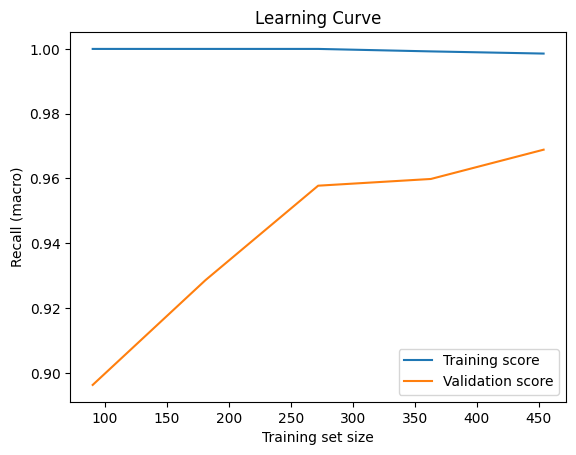

In [139]:
plt.plot(train_sizes, train_scores.mean(axis=1), label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Recall (macro)")
plt.legend()
plt.title("Learning Curve")
plt.show()




## SHAP 

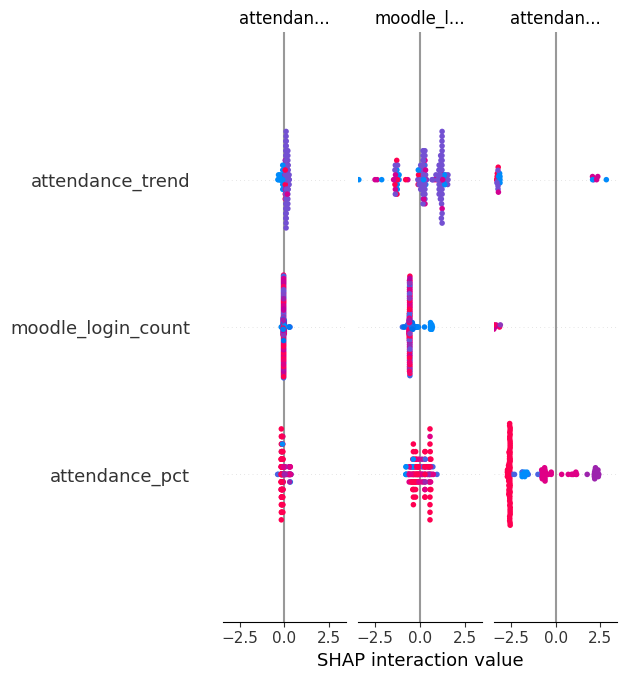

In [150]:
import shap
# Step 1: Build the SHAP explainer. TreeExplainer is the fast, exact method # for tree-based models like XGBoost
explainer = shap.TreeExplainer(final_model)

#Step 2: Compute SHAP values on the test set - explaining predictions on data the model hasn't trained on, consistent with using the untouched
# test set for all "how does this model really behave" questions.For multi-class, this returns one array per class.
shap_values = explainer.shap_values(X_test)

#Step 3: Summary plot - overall feature importance across ALL classes, showing which features matter most and in which direction (color = value).
shap.summary_plot(shap_values, X_test, class_names=label_encoder.classes_)

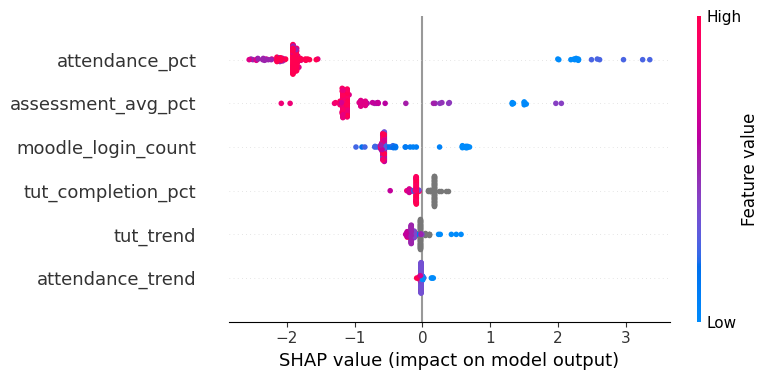

In [153]:
# Step 4: Per-class summary - which features specifically drive a high_risk prediction versus a safe one. This is the more useful view
# for our actual use case, since lecturers care about "why high_risk" specifically, not overall importance blended across all 3 classes.
high_risk_idx = list(label_encoder.classes_).index("high_risk")

# shap_values shape differs by SHAP version - list of arrays (older) vs single 3D array (newer). Handle both.
if isinstance(shap_values, list):
    shap_values_high_risk = shap_values[high_risk_idx]
else:
    shap_values_high_risk = shap_values[:, :, high_risk_idx]

shap.summary_plot(shap_values_high_risk, X_test, show=True)


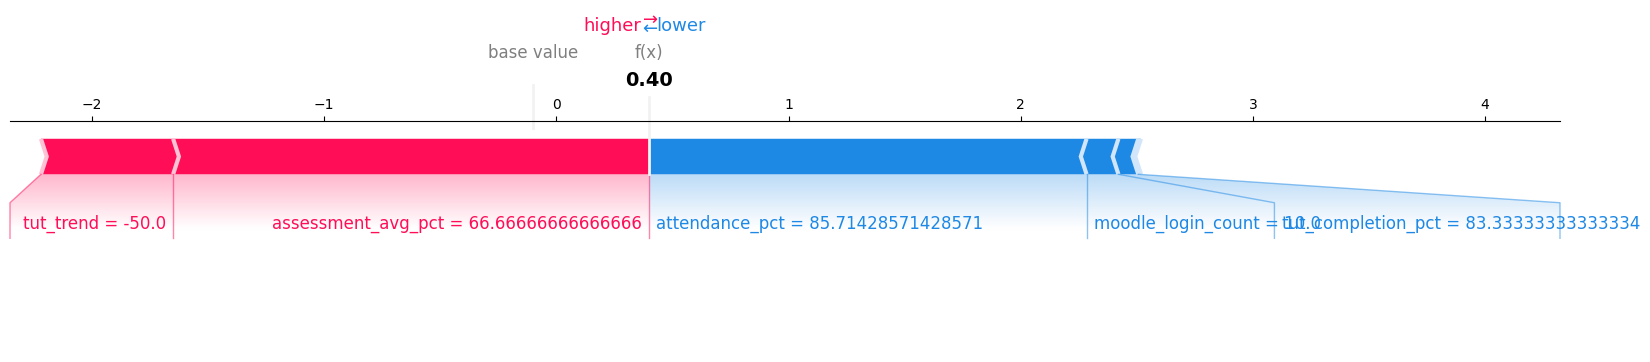

In [160]:
sample_idx = 0  # change this to inspect a specific test-set row


# Step 5: Explain ONE individual prediction - this is exactly the kind of output that will eventually power "why was this student flagged" in
# the lecturer-facing dashboard/alert.
shap.force_plot(
    explainer.expected_value[high_risk_idx] if isinstance(explainer.expected_value, list) 
    else explainer.expected_value[high_risk_idx],
    shap_values_high_risk[sample_idx],
    X_test.iloc[sample_idx],
    matplotlib=True,
)